In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import torch
import multiprocessing as mp
from GAAEST import GAAEST
from lib_3d_OT.utils import *

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
seed = 41
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

In [3]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151674/')
adata.var_names_make_unique()
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151674_truth.csv', sep='\t', index_col=0)

adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]

In [4]:
save_model_file = '/home/dbj/cellvelo/weights.pth'

In [5]:
model = GAAEST.GAAEST(adata, device=device,epochs=600,alpha=10,beta=1,gama=1,lane=1,save_model_file=save_model_file)

In [6]:
adata = model.train()

Begin to train ST data...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:22<00:00, 26.34it/s]


Optimization finished for ST data!
Saving model to /home/dbj/cellvelo/weights.pth


In [8]:
clustering(adata, n_clusters=7, radius=50, key='X', method='mclust', refinement=True,random=2024,n_comp=20)

fitting ...
  |======================================================================| 100%


In [13]:
adata.obs['GAAEST']=adata.obs['3d-OT']

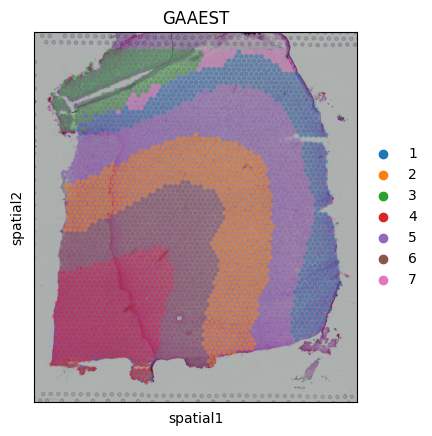

In [15]:
sc.pl.spatial(adata, color='GAAEST', img_key='hires', alpha=0.5, size=1.3)

In [16]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ari = adjusted_rand_score(adata.obs['truth'], adata.obs['GAAEST'])
nmi = normalized_mutual_info_score(adata.obs['truth'], adata.obs['GAAEST'])
ari,nmi

(0.5825684442587207, 0.6958468556610402)